In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline

In [182]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


Tasks:
- Select features -> Reduce dataframe dimensions
    - connectionTime, disconnectTime, doneChargingTime  -> doneDisconnectTimespan, connectionTimespan, doneChargingTimespan
    - kWhRequested, requestedDeparture, minutesAvailable???
    - 
- k-Means, hierarchical clustering -> see clustering notebook
    - Determine number of optimal clusters -> elbow method

Problems to consider:
- Missing user inputs -> Two clusterings: One with user inputs, one without

Bonus:
- Try PCA

In [183]:
# Calculate the durations
full_charging_df['session_duration'] = (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

# Calculate the deviation between the requested departure time and the actual disconnection time
full_charging_df['session_deviation'] = (full_charging_df['requestedDeparture'] - full_charging_df['disconnectTime']).dt.total_seconds() / 60

In [184]:
# Select features for clustering
features = [
    'session_duration',
    'charging_duration',
    'idle_time',
    'session_deviation',
    'kWhRequested',
    'kWhDelivered',
    'minutesAvailable',
]

In [185]:
# X = full_charging_df[features].dropna(subset=['kWhRequested', 'kWhDelivered', 'minutesAvailable'])
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)

(65037, 7)
(44644, 7)


In [186]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,charging_duration,idle_time,session_deviation,kWhRequested,kWhDelivered,minutesAvailable
0,-0.149884,0.242357,-0.373983,0.556258,0.002388,1.086403,0.549982
1,0.543596,1.039915,-0.186137,0.377907,2.177502,1.835067,1.219799
2,0.935557,-0.357202,1.405461,-2.028002,-0.819321,-0.627066,-1.494992
3,-0.938193,-0.816129,-0.465438,-0.178573,-0.819321,-1.013025,-1.469620
4,0.338971,0.212427,0.234434,0.233714,-0.432634,0.007923,0.758031


In [187]:
from sklearn.cluster import KMeans

In [188]:
k_max = 50 # TODO: Is 50 reaosnable?
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

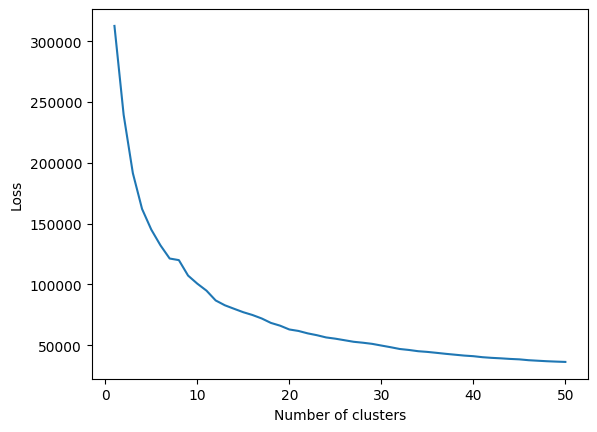

In [189]:
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.show()

(0.0, 20.0)

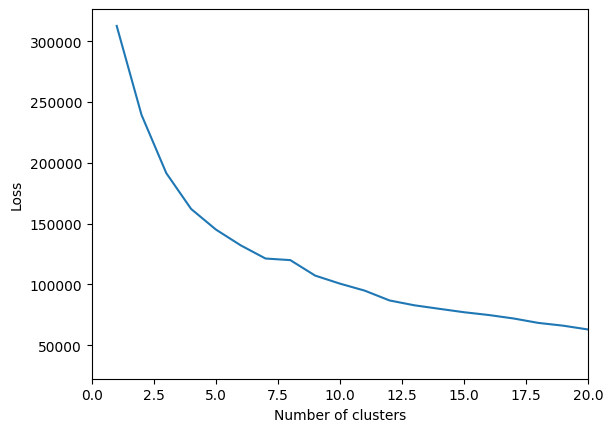

In [190]:
# Zoom in
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,20])

In [191]:
# refit algorithm
seven_means = KMeans(n_clusters=7, n_init='auto')
seven_means.fit(clustering_scaled_df)

# match records to clusters by calling predict
seven_means.predict(clustering_scaled_df)

array([0, 5, 4, ..., 1, 1, 1], dtype=int32)

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


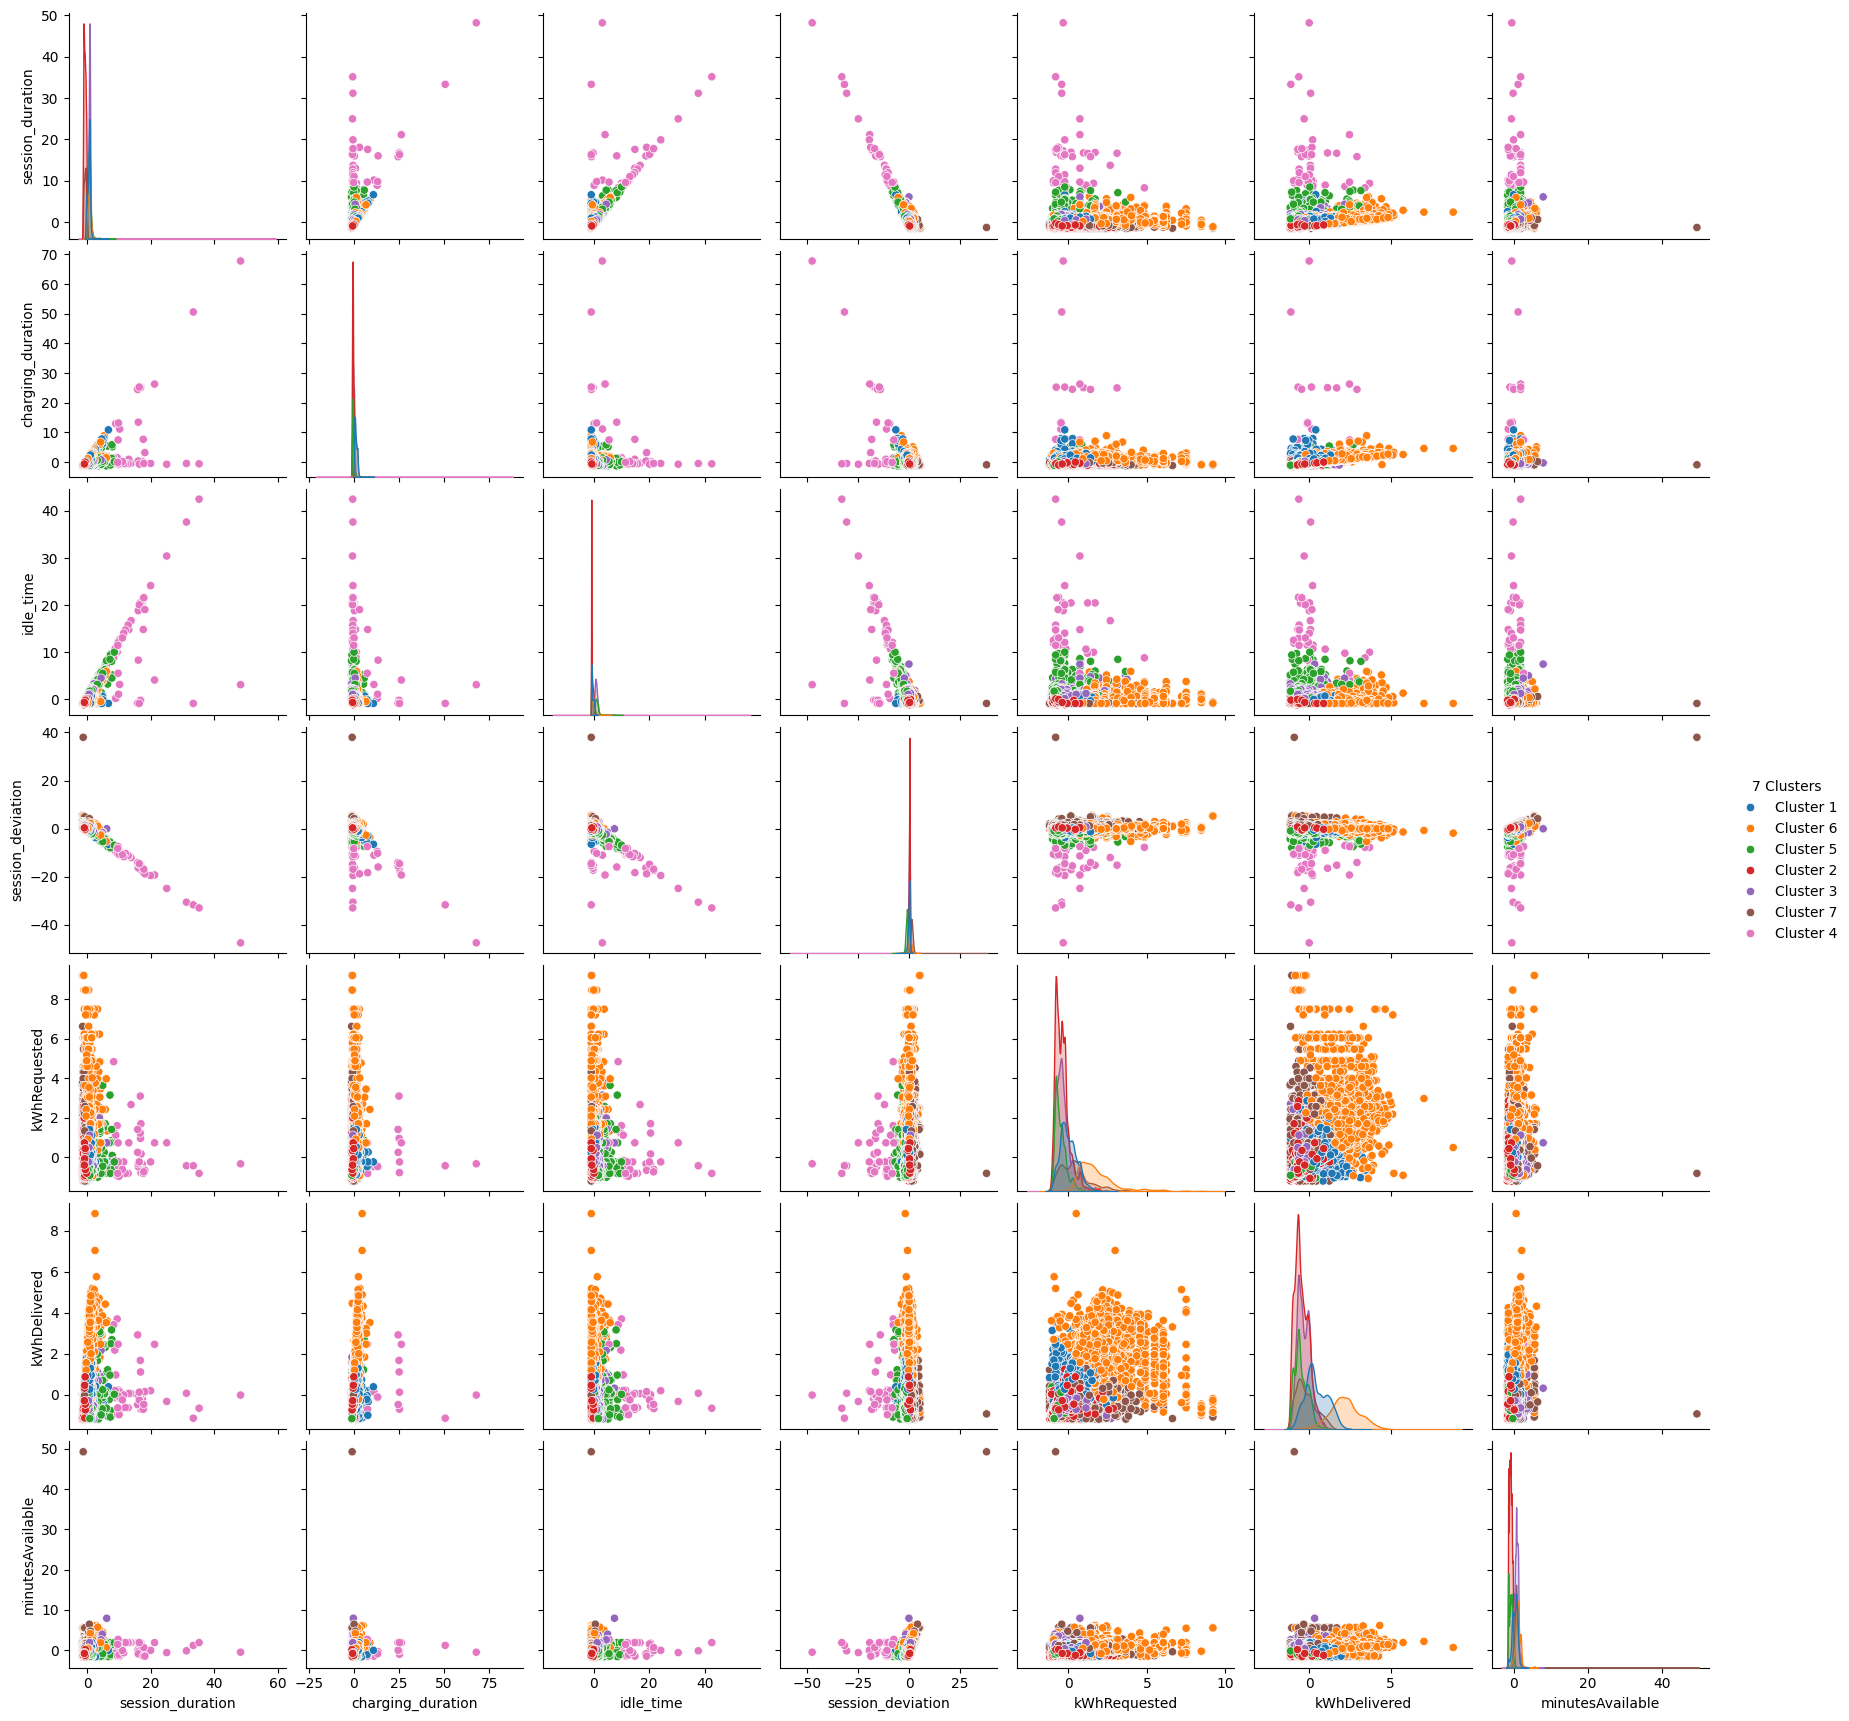

In [192]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5", "Cluster 6", "Cluster 7"]

clustering_scaled_df["7 Clusters"] = seven_means.predict(clustering_scaled)
clustering_scaled_df["7 Clusters"] = clustering_scaled_df["7 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=clustering_scaled_df, hue="7 Clusters")

In [194]:
five_means = KMeans(n_clusters=5, n_init='auto')
five_means.fit(clustering_scaled_df)
clustering_scaled_df["5 Clusters"] = five_means.predict(clustering_scaled)
clustering_scaled_df["5 Clusters"] = clustering_scaled_df["5 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=clustering_scaled_df, hue="5 Clusters")

ValueError: could not convert string to float: 'Cluster 1'